STUDENT PERFORMANCE ANALYSIS

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Getting to know data.

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Changing the column names.

In [21]:
df.columns = [
    'gender',
    'race_ethnicity', 
    'parental_education',
    'lunch',
    'test_prep_course',
    'math_score',
    'reading_score',
    'writing_score'
]

df.head()

,gender,race_ethnicity,parental_education,lunch,test_prep_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Adding an average column to see the avg score of all subjects.

In [22]:
df['avg_subject_scores'] = (df.math_score + df.reading_score + df.writing_score) / 3
df.avg_subject_scores = df.avg_subject_scores.round(2)
df.head()
df.avg_subject_scores.describe()


count    1000.000000
mean       67.770580
std        14.257311
min         9.000000
25%        58.330000
50%        68.330000
75%        77.670000
max       100.000000
Name: avg_subject_scores, dtype: float64

The difference between the means of male and female students?

In [23]:
df.groupby('gender')['avg_subject_scores'].mean(),round(2)

(gender
 female    69.569498
 male      65.837303
 Name: avg_subject_scores, dtype: float64,
 2)

Let's see this on a graph.

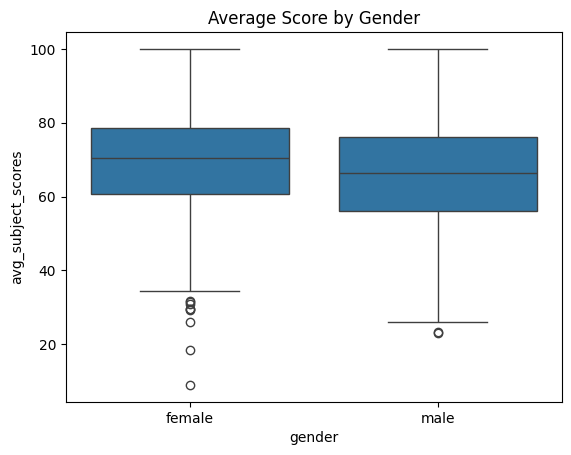

In [24]:
sns.boxplot(x='gender', y='avg_subject_scores', data=df)
plt.title('Average Score by Gender')
plt.show()

In [ ]:
**Observations:**
- Female students are better in general


How does the test preb affect the scores?

In [37]:
df.groupby(['test_prep_course', 'gender'])['avg_subject_scores'].mean().round(2)

test_prep_course  gender
completed         female    74.46
                  male      70.78
none              female    66.88
                  male      63.04
Name: avg_subject_scores, dtype: float64

Let's see this on a graph.

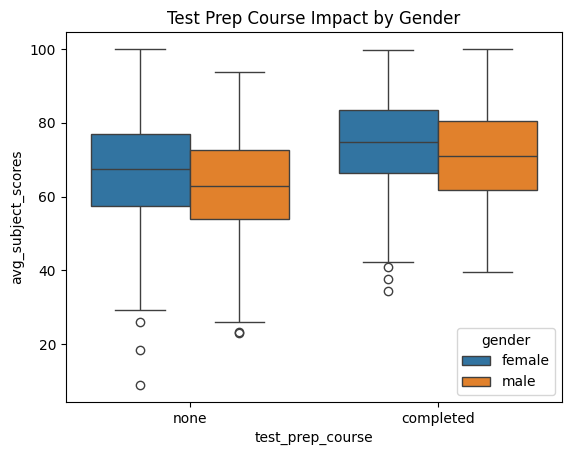

In [38]:
sns.boxplot(x='test_prep_course', y='avg_subject_scores', hue='gender', data=df)
plt.title('Test Prep Course Impact by Gender')
plt.show()

How is parental_education affecting the student's score?

**Observations:**
- Test prep helps students perform better.
- Female students are better than male students.

In [51]:
df.groupby(['parental_education', 'gender'])['avg_subject_scores'].mean().round(2)


parental_education  gender
associate's degree  female    71.12
                    male      67.87
bachelor's degree   female    74.67
                    male      68.78
high school         female    64.75
                    male      61.58
master's degree     female    73.65
                    male      73.52
some college        female    71.00
                    male      65.72
some high school    female    65.56
                    male      64.64
Name: avg_subject_scores, dtype: float64

Let' see this on a graph.

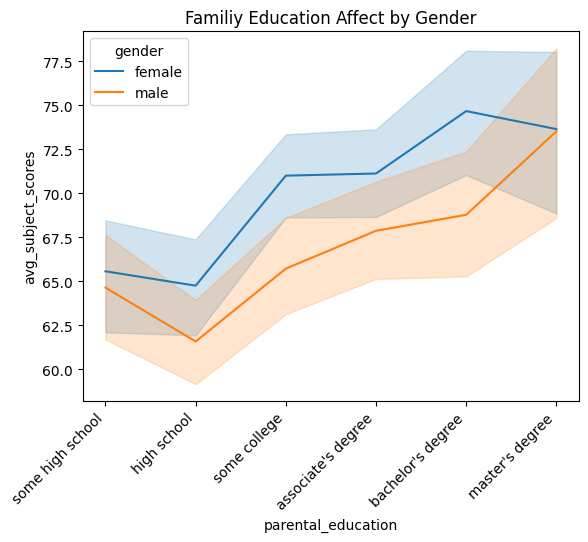

In [58]:

edu_order = [
    'some high school',
    'high school', 
    'some college',
    "associate's degree",
    "bachelor's degree",
    "master's degree"
]
df['parental_education'] = pd.Categorical(
    df['parental_education'], 
    categories=edu_order, 
    ordered=True
)
sns.lineplot(x='parental_education', y='avg_subject_scores', hue='gender', data=df)
plt.title('Familiy Education Affect by Gender')
plt.xticks(rotation=45, ha='right')
plt.show()

**Observations:**
- Some high school > high school
- Master's degree increases dramatically. What could affect this?


In [61]:
df.groupby('parental_education')['avg_subject_scores'].count()

/var/folders/rj/l_c296wd0lv_r47c3c2pf1cw0000gn/T/ipykernel_37645/2599882452.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('parental_education')['avg_subject_scores'].count()


parental_education
some high school      179
high school           196
some college          226
associate's degree    222
bachelor's degree     118
master's degree        59
Name: avg_subject_scores, dtype: int64

Now I will check the other aspects.

In [63]:
df.head()
df.groupby(['lunch', 'gender'])['avg_subject_scores'].mean().round(2)

lunch         gender
free/reduced  female    63.22
              male      61.04
standard      female    73.22
              male      68.36
Name: avg_subject_scores, dtype: float64

Lets see this on the graph.

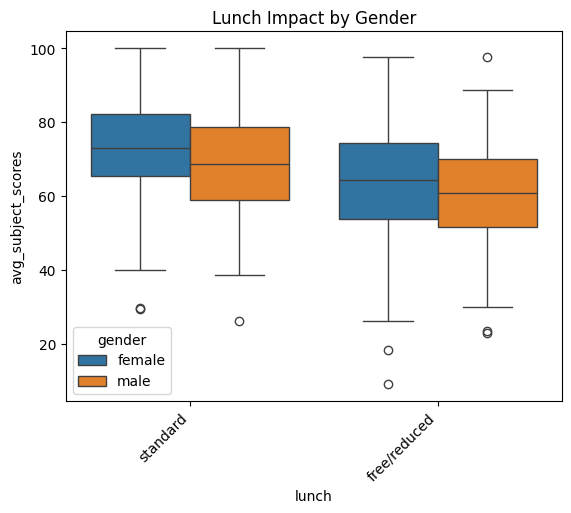

In [64]:
sns.boxplot(x='lunch', y='avg_subject_scores', hue='gender', data=df)
plt.title('Lunch Impact by Gender')
plt.xticks(rotation=45, ha='right')
plt.show()

**Observations:**
- Students under standard luch program are tend to perform better compared to those under free/reduced
- When I compare the difference between male and female students under the same program I see that the scores are close to each other.
- Gender Difference: ~4 puan, Lunch difference: ~10 puan

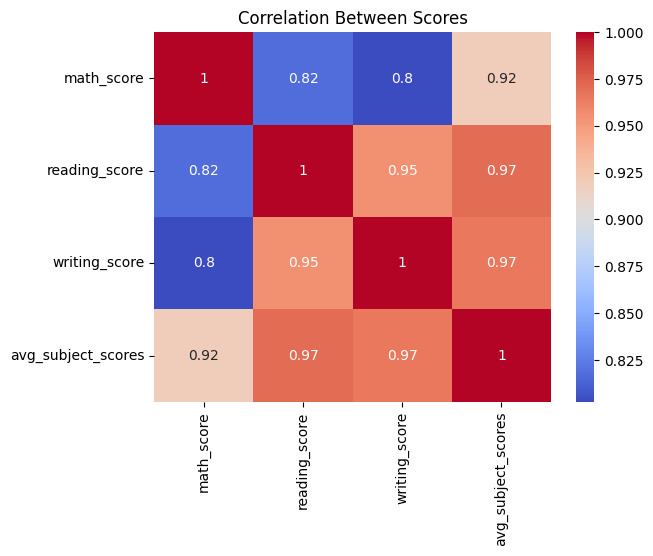

In [65]:
sns.heatmap(df[['math_score', 'reading_score', 'writing_score', 'avg_subject_scores']].corr(), 
            annot=True, 
            cmap='coolwarm')
plt.title('Correlation Between Scores')
plt.show()

**Observations:**
- The highest correlation is between writing and reading subjects.
- As these two subjects are related, we can say if writing is high, reading is high and vice versa.


In this project, I analyzed the differences in exam performance 
across gender, test preparation, and parental education level.

Key findings:
- Female students scored approximately 4 points higher than male 
  students on average.
- Students who completed the test preparation course performed 
  better regardless of gender.
- As parental education level increases, student scores generally 
  increase as well. However, the master's degree group should be 
  interpreted carefully as it contains only 59 students.
- Students with a standard lunch program scored approximately 10 points 
  higher than those with free/reduced lunch — the strongest predictor 
  of performance in this dataset.

- Tableau dashboard reveals that reading and writing scores move together across all education levels, consistent with the high correlation found in the heatmap. Math scores remain consistently lower across all groups.

Next steps: A deeper analysis could explore the interaction between 
socioeconomic status (lunch program) and parental education, or 
build a simple model to predict student scores.